In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [88]:
df = pd.read_csv("projectos.csv")

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Number                245 non-null    object 
 1   Active                245 non-null    object 
 2   Project Name          245 non-null    object 
 3   Project Type          245 non-null    object 
 4   Geographical scope    245 non-null    object 
 5   Project manager       245 non-null    object 
 6   State                 245 non-null    object 
 7   Percent complete      245 non-null    float64
 8   Project size          245 non-null    object 
 9   Project organization  245 non-null    object 
 10  Planned Go Live date  245 non-null    object 
 11  Project target phase  72 non-null     object 
 12  Actual Go Live date   48 non-null     object 
 13  Actual end date       0 non-null      float64
 14  BG                    245 non-null    object 
 15  Closed                1

In [90]:
df.head()

,Number,Active,Project Name,Project Type,Geographical scope,Project manager,State,Percent complete,Project size,Project organization,...,Domain,Domain Path,Last WAR,Project Health,Project type,Recurrent activity,Planned start date,Actual start date,On-hold,Unnamed: 25
0,PRJ0075198,VERDADERO,TCO - FIS - ABRERA - VW210 IP,Shopfloor JIT/TCO,ABRERA FIS,BENAVENT Pablo,Work in progress,26.47,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,global,/,PRJSTAT0075304,Green,Regular,FALSO,1/2/2025 17:01,NaN,FALSO,NaN
1,PRJ0073962,VERDADERO,TCO - FCM - ALLENJOIE FHS - GEN2 New automated...,Shopfloor JIT/TCO,ALLENJOIE FCM,MAUVAIS Julien,Work in progress,52.17,LARGE,GIT/IT EMEA/MES & Digital Shopfloor projects,...,global,/,PRJSTAT0075248,Yellow,Regular,FALSO,18/01/2024 08:00:00,18/01/2024 08:00:00,VERDADERO,NaN
2,PRJ0074556,VERDADERO,TCO - FCM - ALLENJOIE FHS - Tank XL,Shopfloor JIT/TCO,ALLENJOIE FHS,THIERY Jean-Francois,Work in progress,95.85,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,global,/,PRJSTAT0075265,Yellow,Regular,FALSO,12/8/2024 8:00,12/8/2024 8:00,FALSO,NaN
3,PRJ0075087,VERDADERO,TCO - FCM - ALLENJOIE FHS - STELLANTIS - XL694...,Shopfloor JIT/TCO,ALLENJOIE FHS,MAUVAIS Julien,Work in progress,20.90,SMALL,GIT/IT EMEA/MES & Digital Shopfloor projects,...,global,/,PRJSTAT0075325,Green,Regular,FALSO,8/1/2025 8:00,15/01/2025 09:52:03,VERDADERO,NaN
4,PRJ0075456,VERDADERO,TCO – FCM - ALMUSSAFES - FORD - C482 Welding l...,Shopfloor JIT/TCO,ALMUSSAFES FCM,BENAVENT Pablo,Work in progress,24.30,MEDIUM,GIT/IT EMEA/MES & Digital Shopfloor projects,...,global,/,PRJSTAT0075307,Green,Regular,FALSO,12/5/2025 8:00,12/5/2025 8:00,FALSO,NaN


In [91]:
df.isnull().sum()

Number                    0
Active                    0
Project Name              0
Project Type              0
Geographical scope        0
Project manager           0
State                     0
Percent complete          0
Project size              0
Project organization      0
Planned Go Live date      0
Project target phase    173
Actual Go Live date     197
Actual end date         245
BG                        0
Closed                  244
Domain                    0
Domain Path               0
Last WAR                 13
Project Health           13
Project type              0
Recurrent activity        0
Planned start date        0
Actual start date        18
On-hold                   0
Unnamed: 25             245
dtype: int64

In [92]:
df[["Project target phase", "Actual Go Live date", "Actual end date"]]= df[["Project target phase", "Actual Go Live date", "Actual end date"]].fillna("No Establecido")

In [93]:
df["Closed"]=df["Closed"].fillna("Sin Cerrar")

In [94]:
df["Last WAR"]=df["Last WAR"].fillna("Sin Actualizacion")

In [95]:
df["Project Health"]=df["Project Health"].fillna("Sin Actualizacion")

In [96]:
df["Actual start date"]=df["Actual start date"].fillna("No establecido")

In [97]:
df.pop("Unnamed: 25")

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
240   NaN
241   NaN
242   NaN
243   NaN
244   NaN
Name: Unnamed: 25, Length: 245, dtype: float64

In [98]:
project_type = df["Project Type"].value_counts().reset_index()
project_type

,Project Type,count
0,Shopfloor JIT/TCO,80
1,FCS roll-outs,75
2,New software or release,46
3,Shopfloor LES/NEO,13
4,Studies / Moves / Solution Selection / Other,8
5,New Site infrastructure,7
6,Overall Project Coordination,6
7,Shopfloor DMC/SPC,5
8,New infrastructure,3
9,ITAC,1


In [99]:
Filtro_Index = project_type.set_index('Project Type')
Filtro_Index

,count
Project Type,
Shopfloor JIT/TCO,80
FCS roll-outs,75
New software or release,46
Shopfloor LES/NEO,13
Studies / Moves / Solution Selection / Other,8
New Site infrastructure,7
Overall Project Coordination,6
Shopfloor DMC/SPC,5
New infrastructure,3


Text(0, 0.5, 'Frecuencia')

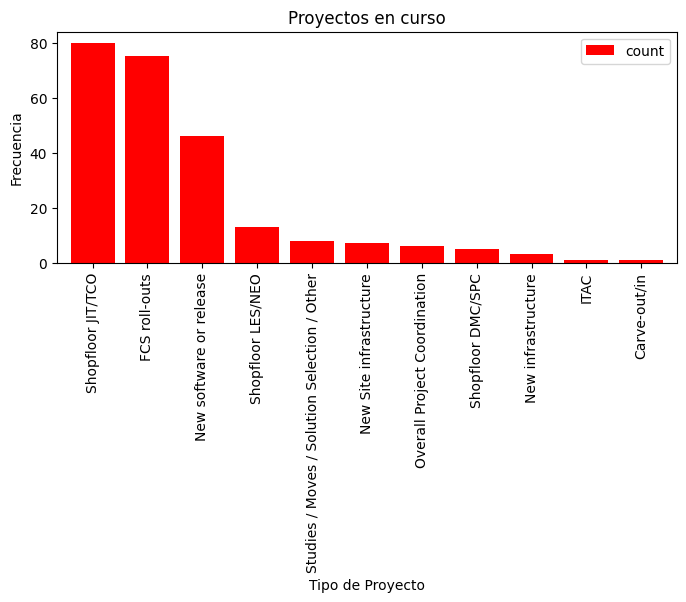

In [100]:
Filtro_Index.plot(kind = 'bar', width=0.8, figsize=(8,3), color= "red")
plt.title('Proyectos en curso')
plt.xlabel('Tipo de Proyecto')
plt.ylabel('Frecuencia')

In [101]:
geo_scope = df["Geographical scope"].value_counts().reset_index()
geo_scope


,Geographical scope,count
0,WORLD WIDE,20
1,BRAZIL,9
2,PUEBLA HQ,7
3,BRAGANCA,6
4,LIPPSTADT 2 HQH & FES R&D,5
...,...,...
121,TRNAVA FAS,1
122,TIMISOARA GE R&D,1
123,WALBRZYCH Pneumatic,1
124,WUHAN FIS,1


In [102]:
filtro_geo = geo_scope[geo_scope['count']>3]
filtro_geo

,Geographical scope,count
0,WORLD WIDE,20
1,BRAZIL,9
2,PUEBLA HQ,7
3,BRAGANCA,6
4,LIPPSTADT 2 HQH & FES R&D,5
5,MLADA BOLESLAV FCM Bezdecin,5
6,PARIS TECH CENTER,5
7,LIPPSTADT 1,4
8,MLADA BOLESLAV FIS,4
9,GOIANA,4


In [103]:
filtro_geo_index = filtro_geo.set_index("Geographical scope")
filtro_geo_index

,count
Geographical scope,
WORLD WIDE,20
BRAZIL,9
PUEBLA HQ,7
BRAGANCA,6
LIPPSTADT 2 HQH & FES R&D,5
MLADA BOLESLAV FCM Bezdecin,5
PARIS TECH CENTER,5
LIPPSTADT 1,4
MLADA BOLESLAV FIS,4


Text(0.5, 0, 'Regiones')

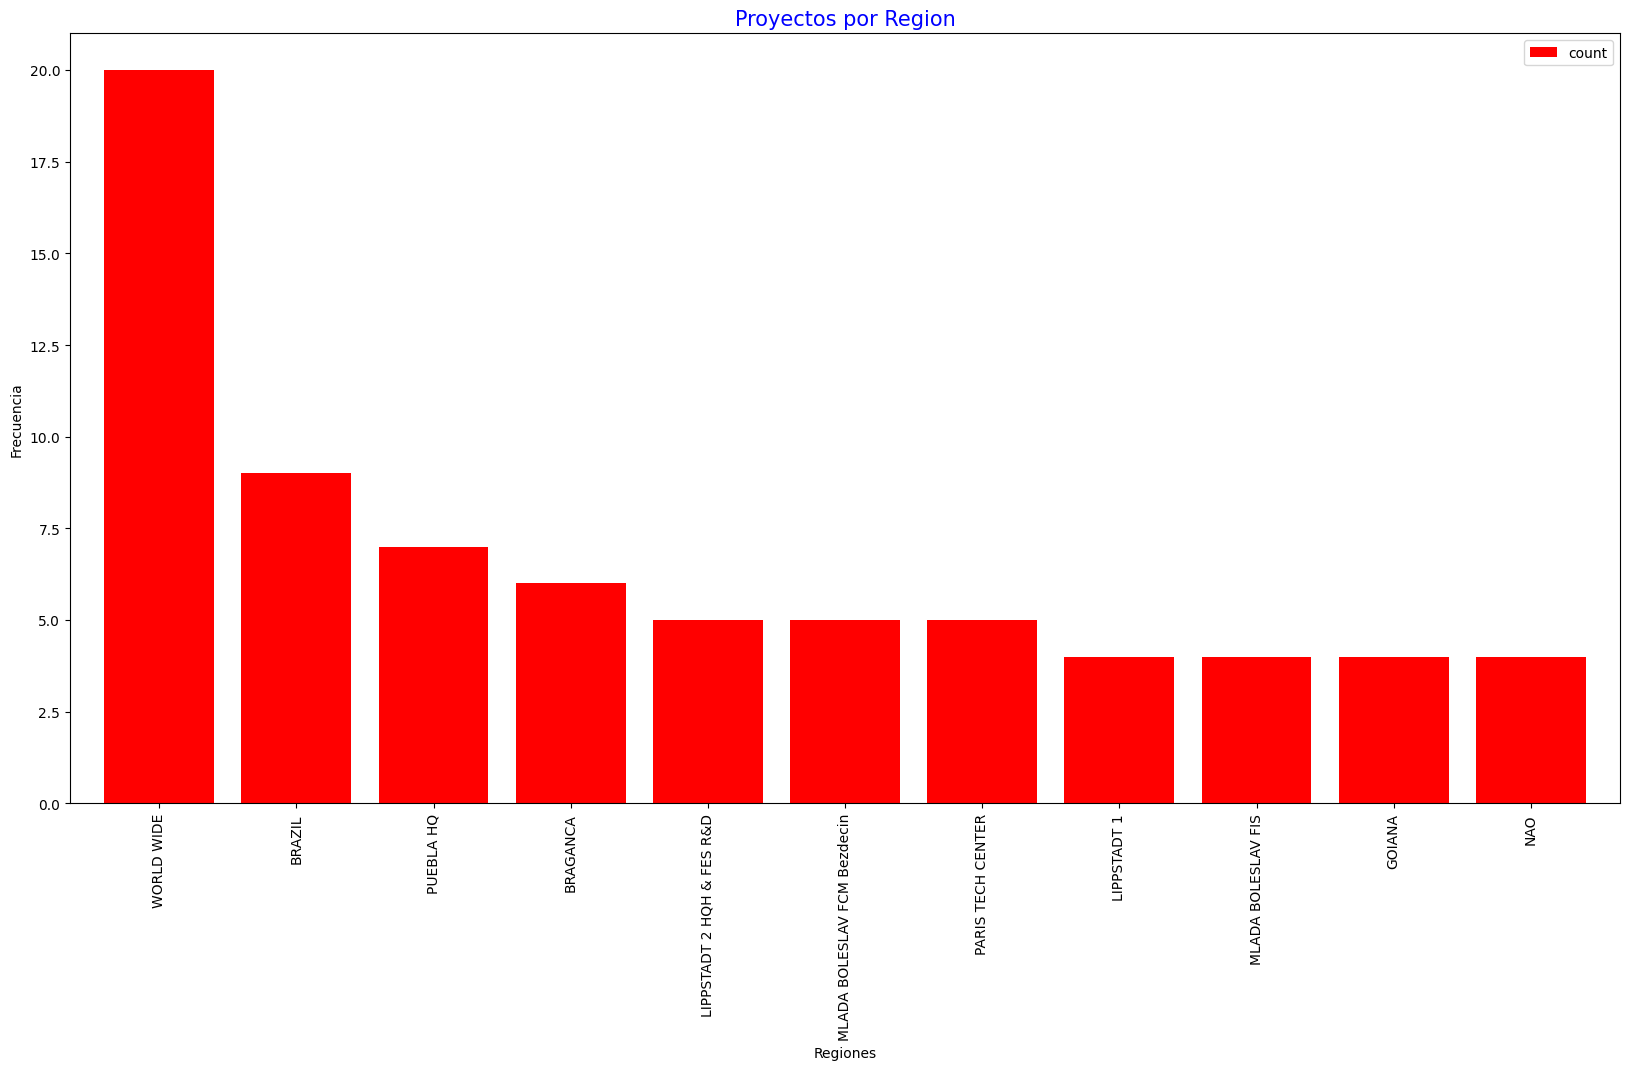

In [104]:
filtro_geo_index.plot(kind="bar", width= 0.8, figsize = (20,10), color="red")
plt.title("Proyectos por Region",size = 15, color="blue")
plt.ylabel("Frecuencia")
plt.xlabel("Regiones")

In [105]:
project_manager = df["Project manager"].value_counts().reset_index()
project_manager

,Project manager,count
0,SOUZA Alexandre,15
1,BENAVENT Pablo,12
2,SVARICEK Dan,9
3,LOUBET Diana,9
4,MALTER Karsten,7
...,...,...
115,BERTOCCHI Vincent,1
116,ROBERT Jean-Claude,1
117,TRAUTMANN Roland,1
118,CHEN Ken,1


In [106]:
filtro_project_manager = project_manager[project_manager['count']>3]
filtro_project_manager

,Project manager,count
0,SOUZA Alexandre,15
1,BENAVENT Pablo,12
2,SVARICEK Dan,9
3,LOUBET Diana,9
4,MALTER Karsten,7
5,CAEIRO Helder,6
6,LOURENCO Douglas,6
7,FENETRE Teddy,5
8,NITSCKIE Jade,5
9,CUCHEROUSSET Christelle,4


In [107]:
filtro_index_manager=filtro_project_manager.set_index("Project manager")
filtro_index_manager

,count
Project manager,
SOUZA Alexandre,15
BENAVENT Pablo,12
SVARICEK Dan,9
LOUBET Diana,9
MALTER Karsten,7
CAEIRO Helder,6
LOURENCO Douglas,6
FENETRE Teddy,5
NITSCKIE Jade,5


Text(0.5, 0, 'Gerente')

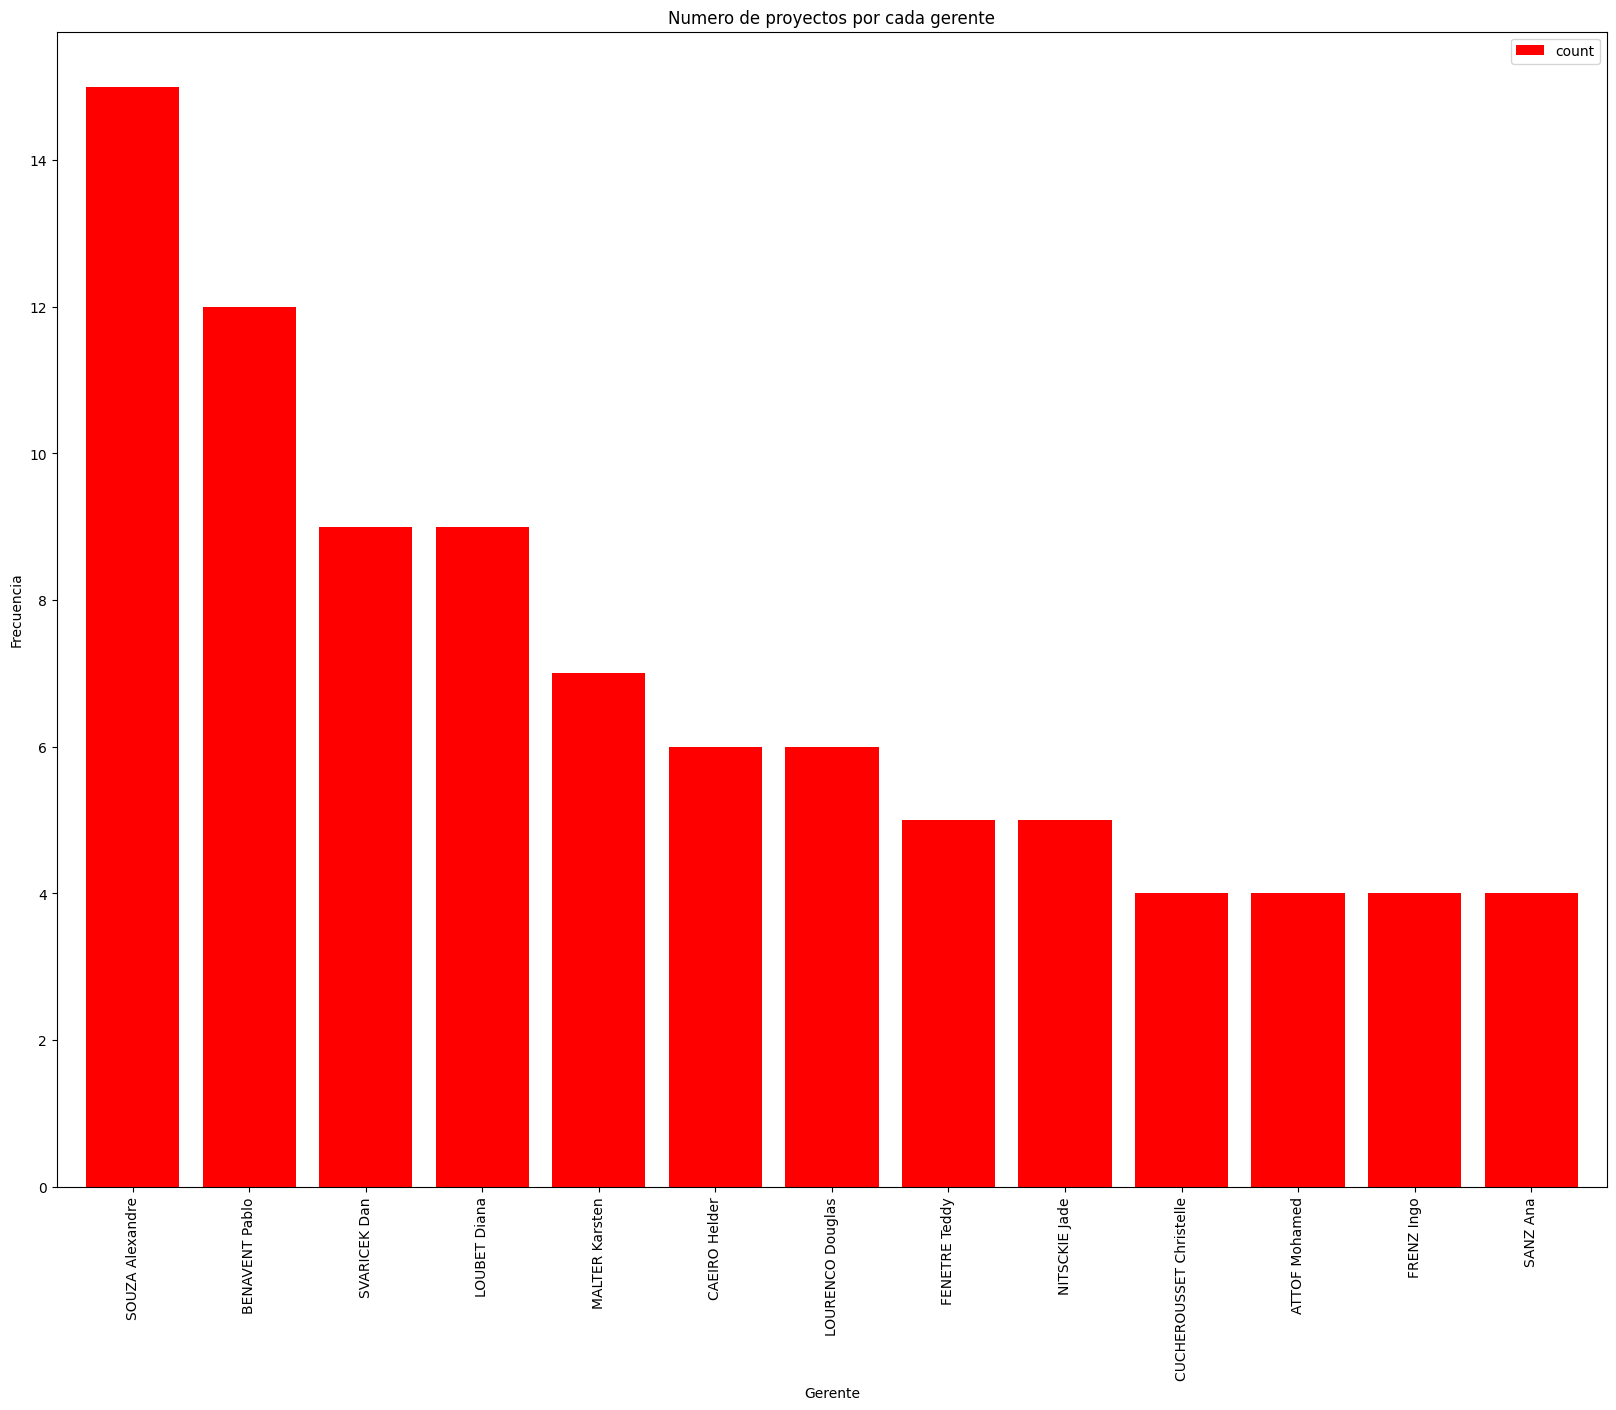

In [108]:
filtro_index_manager.plot(kind="bar",width=0.8,figsize= (20,15),color="red")
plt.title("Numero de proyectos por cada gerente")
plt.ylabel("Frecuencia")
plt.xlabel("Gerente")

In [109]:
state=df["State"].value_counts().reset_index()
state

,State,count
0,Work in progress,232
1,Pending,12
2,Open,1


In [110]:
state_index = state.set_index("State")
state_index

,count
State,
Work in progress,232
Pending,12
Open,1


Text(0.5, 0, 'Estado')

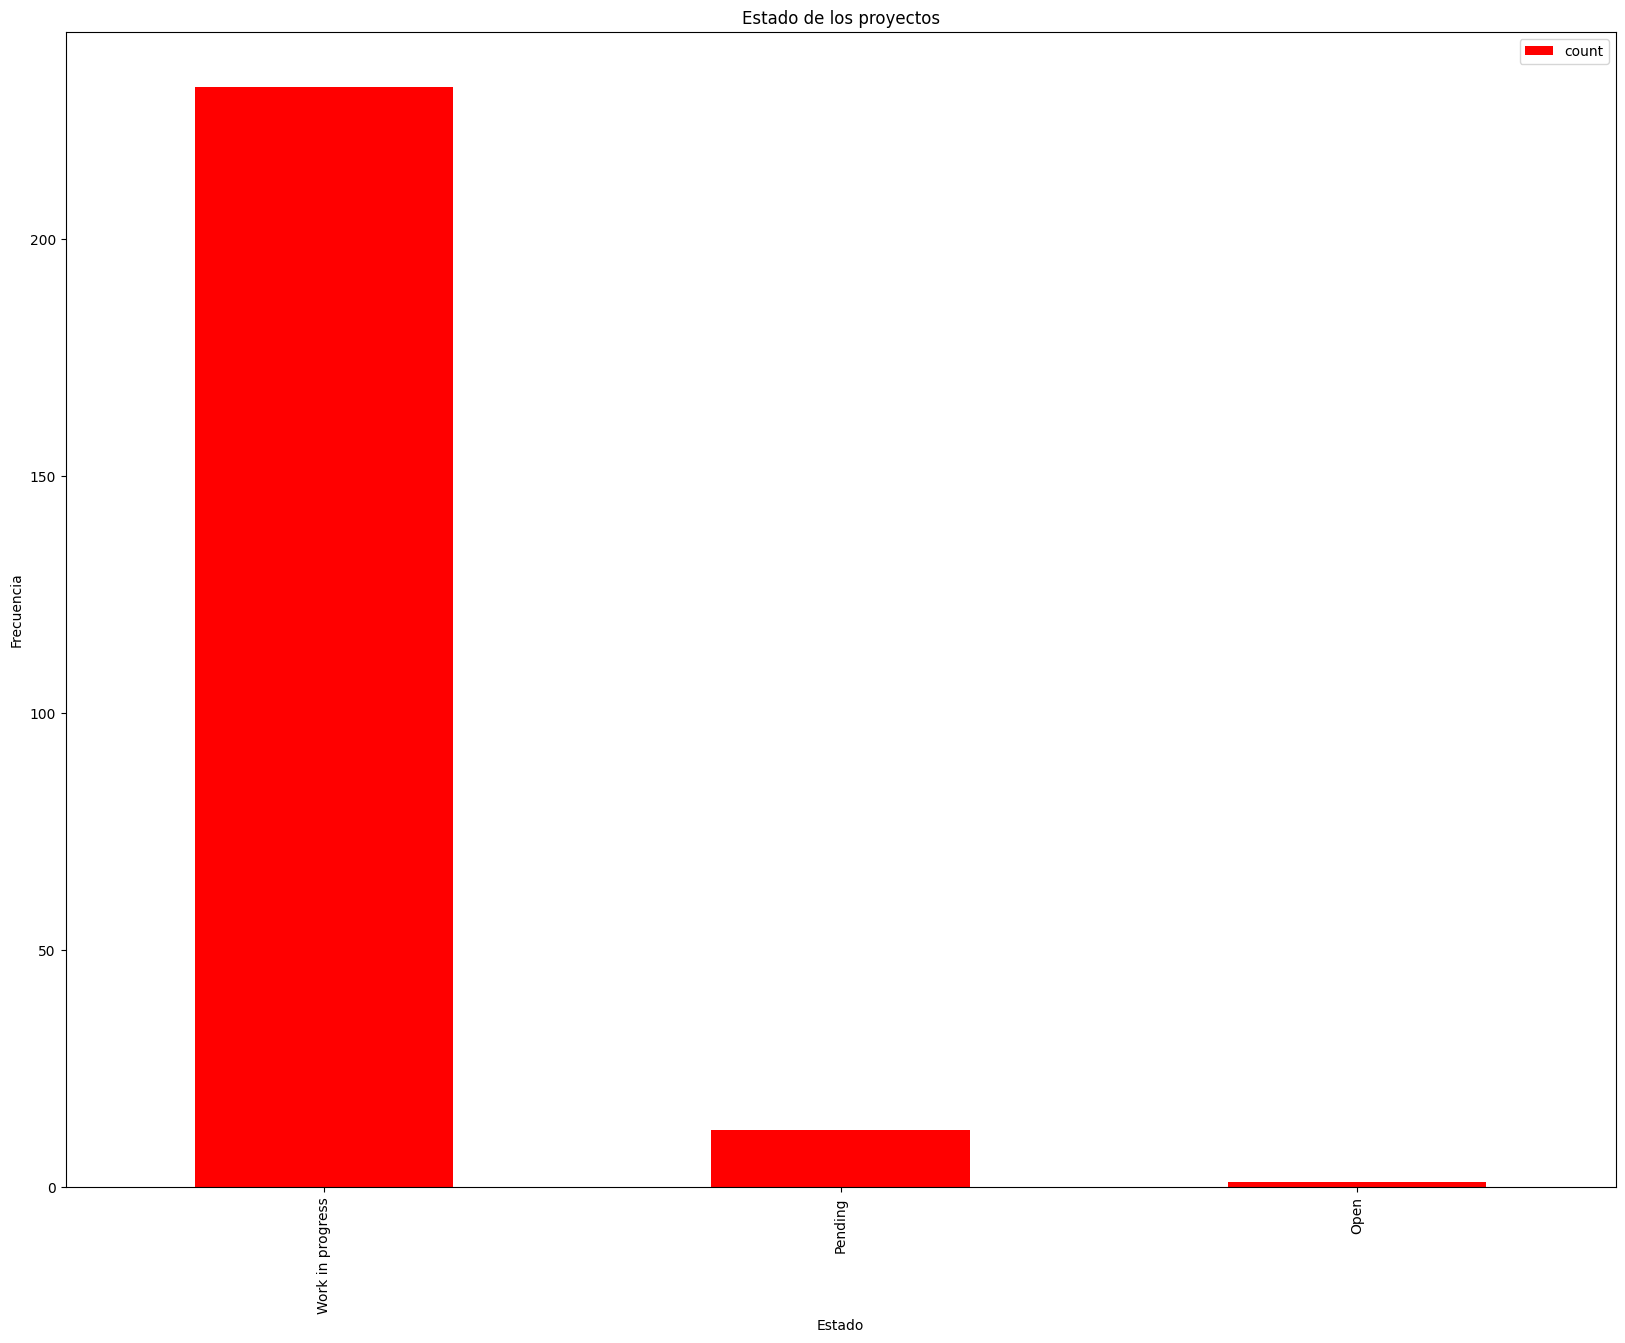

In [111]:
state_index.plot(kind="bar",width=0.5,figsize= (20,15),color="red")
plt.title("Estado de los proyectos")
plt.ylabel("Frecuencia")
plt.xlabel("Estado")

In [112]:
project_size= df["Project size"].value_counts().reset_index()
project_size

,Project size,count
0,MEDIUM,103
1,LARGE,81
2,SMALL,61


In [113]:
project_size_imdex = project_size.set_index("Project size")
project_size_imdex

,count
Project size,
MEDIUM,103
LARGE,81
SMALL,61


Text(0.5, 0, 'Tamaño')

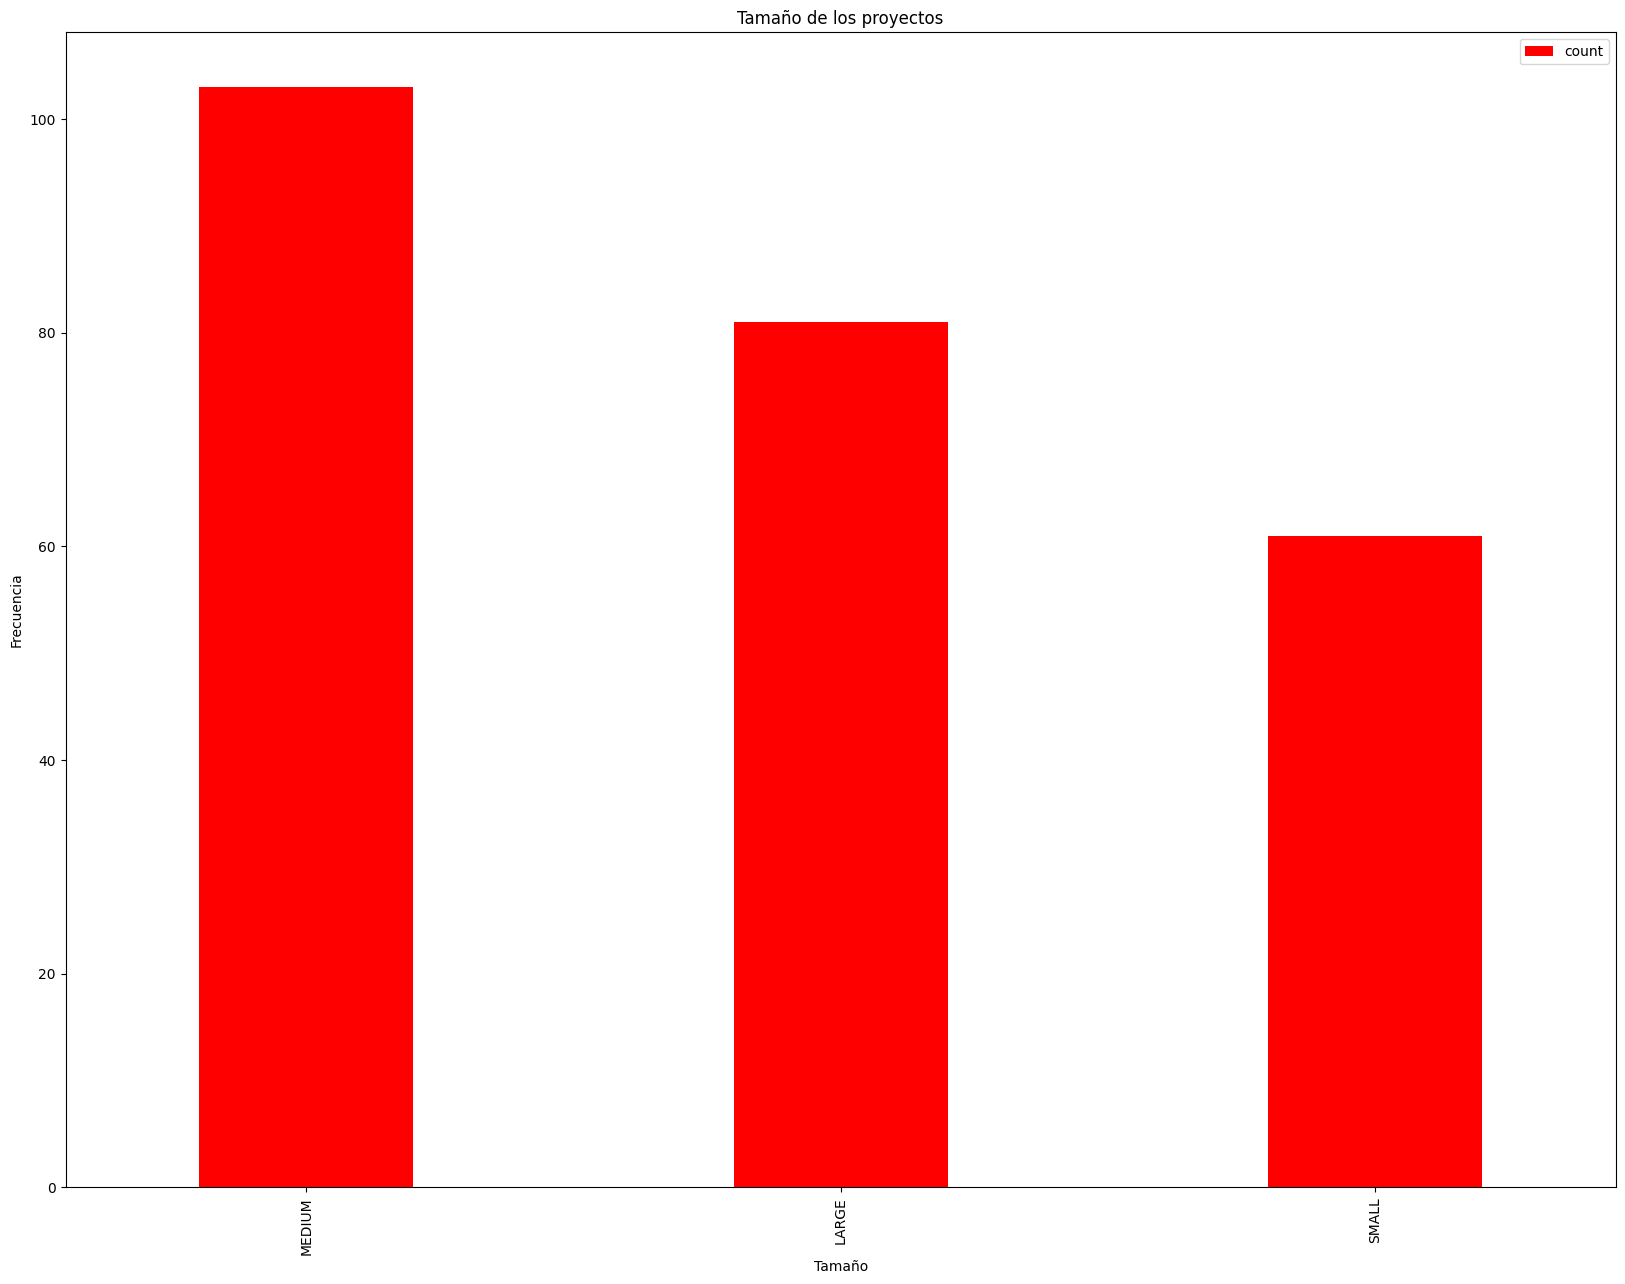

In [114]:
project_size_imdex.plot(kind="bar",width=0.4,figsize= (20,15),color="red")
plt.title("Tamaño de los proyectos")
plt.ylabel("Frecuencia")
plt.xlabel("Tamaño")

In [115]:
project_org=df["Project organization"].value_counts().reset_index()
project_org

,Project organization,count
0,GIT/IT EMEA/MES & Digital Shopfloor projects,61
1,GIT/IT EMEA/Applications rollouts & Level 2 Su...,42
2,GIS/ITOP SAO./IT OP SAO shared/ITOP SAO FCS & ...,15
3,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA MES ...,14
4,GIT/IT NAO/MES Applications & DT/Mexico MES,13
5,GIT/Applications/Engineering / R&D Domain,10
6,GIT/Applications,10
7,GIT/IT NAO/NAO Applications/FCS,9
8,GIT/IT NAO,8
9,GIS/ITOP ASIA/IT OP Asia Shared/ITOP ASIA Infr...,8


Text(0.5, 0, 'Organizacion')

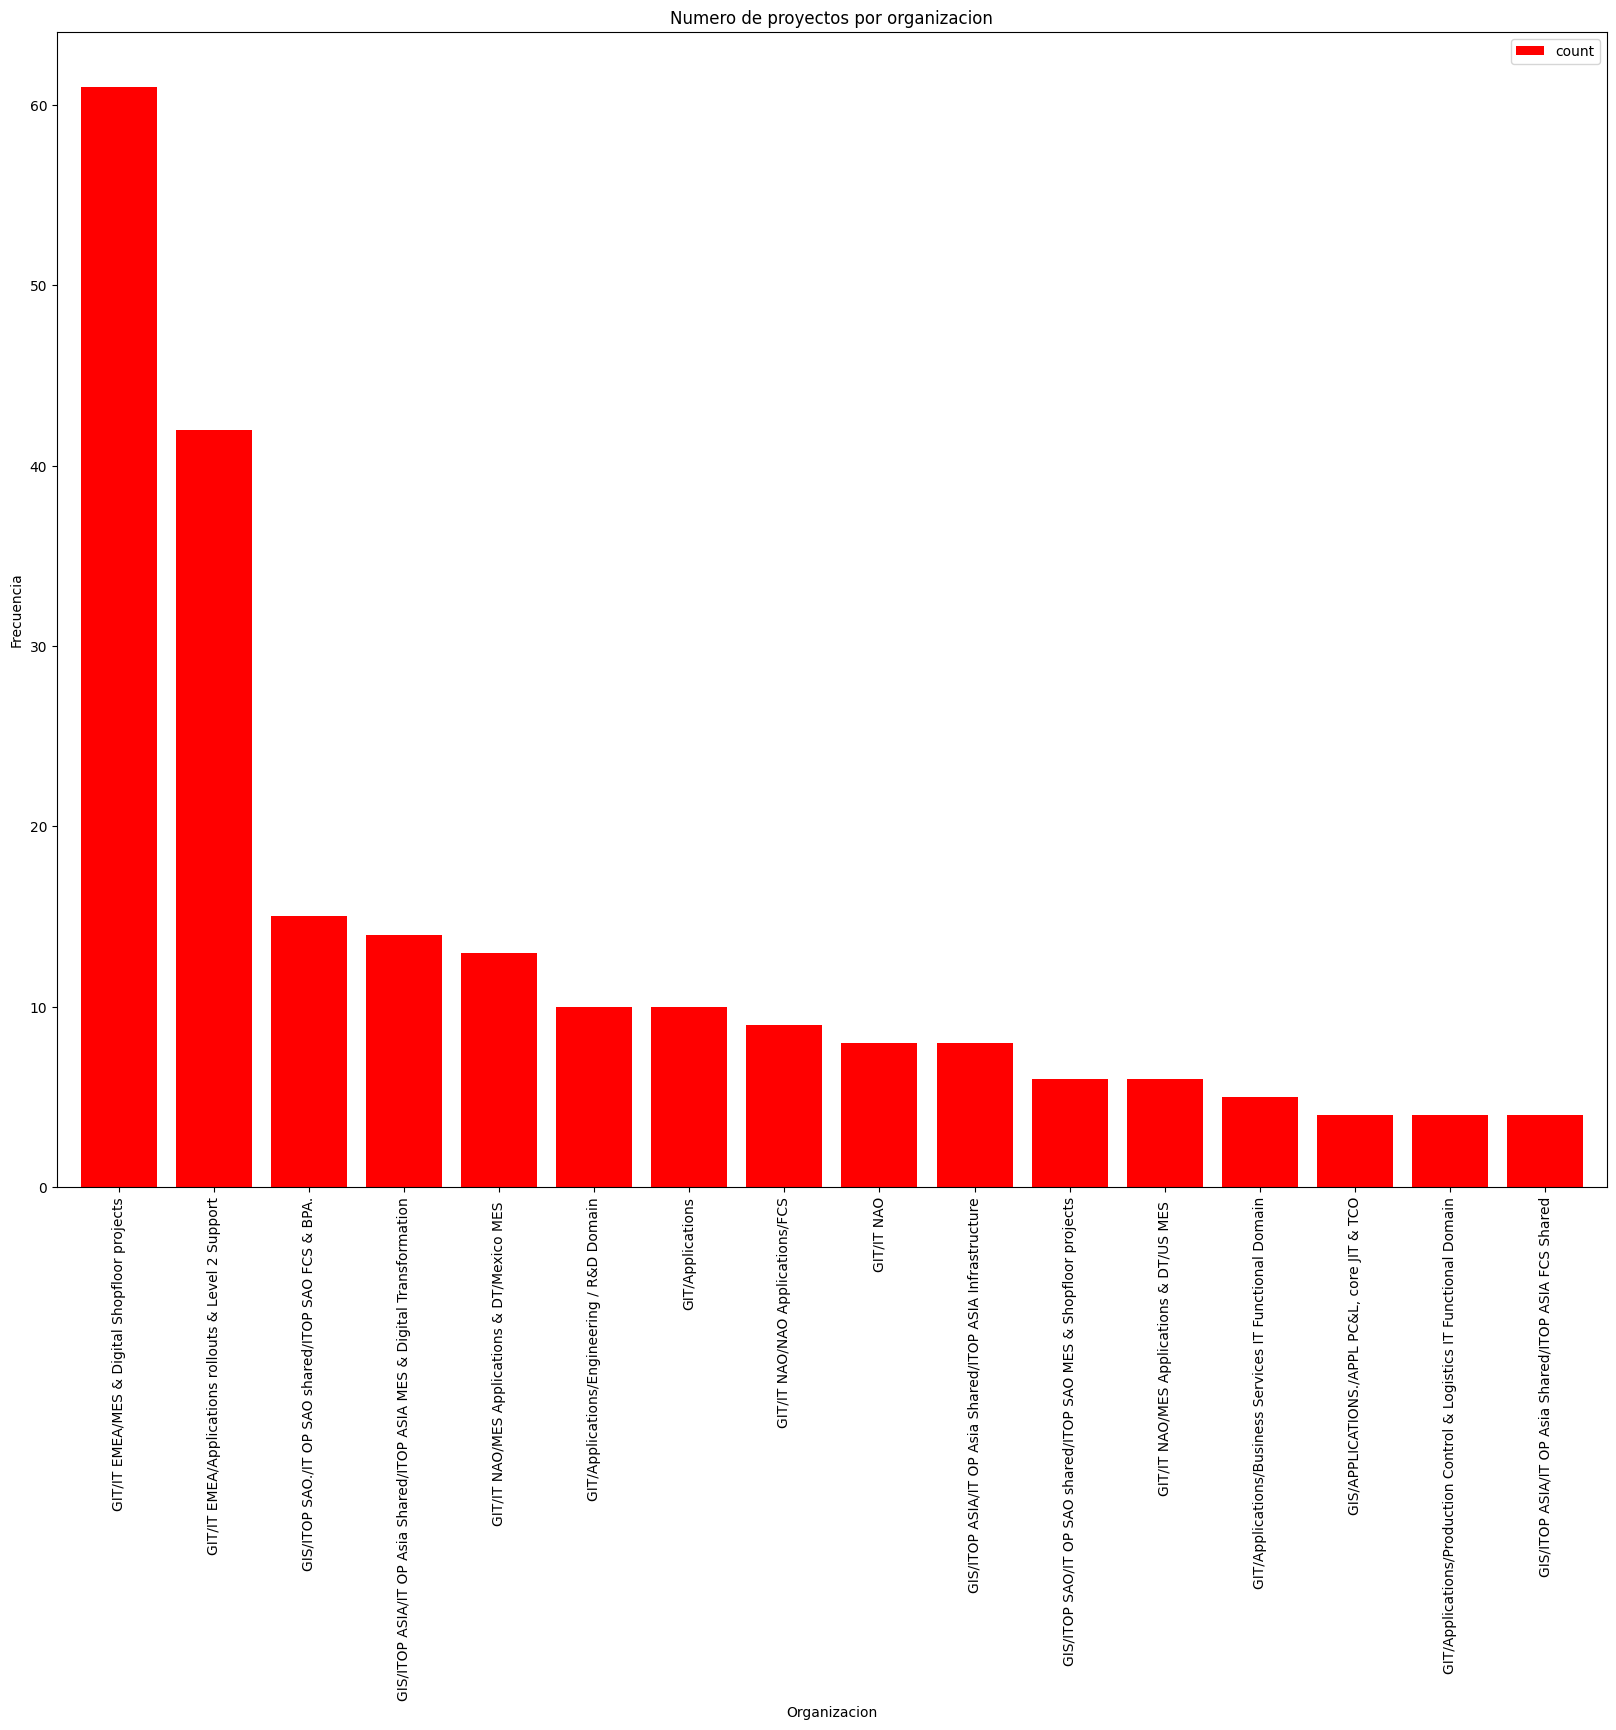

In [116]:
filtro_project_org=project_org[project_org['count']>3]
filtro_index_org= filtro_project_org.set_index("Project organization")
filtro_index_org.plot(kind="bar",width=0.8,figsize= (20,15),color="red")
plt.title("Numero de proyectos por organizacion")
plt.ylabel("Frecuencia")
plt.xlabel("Organizacion")

In [117]:
bg=df["BG"].value_counts().reset_index()
bg

,BG,count
0,FIS,69
1,FCM,57
2,FAS,45
3,GROUP,40
4,FCE,8
5,FLG,8
6,FES,6
7,HQH,6
8,FLV,5
9,SAS,1


Text(0.5, 0, 'BG')

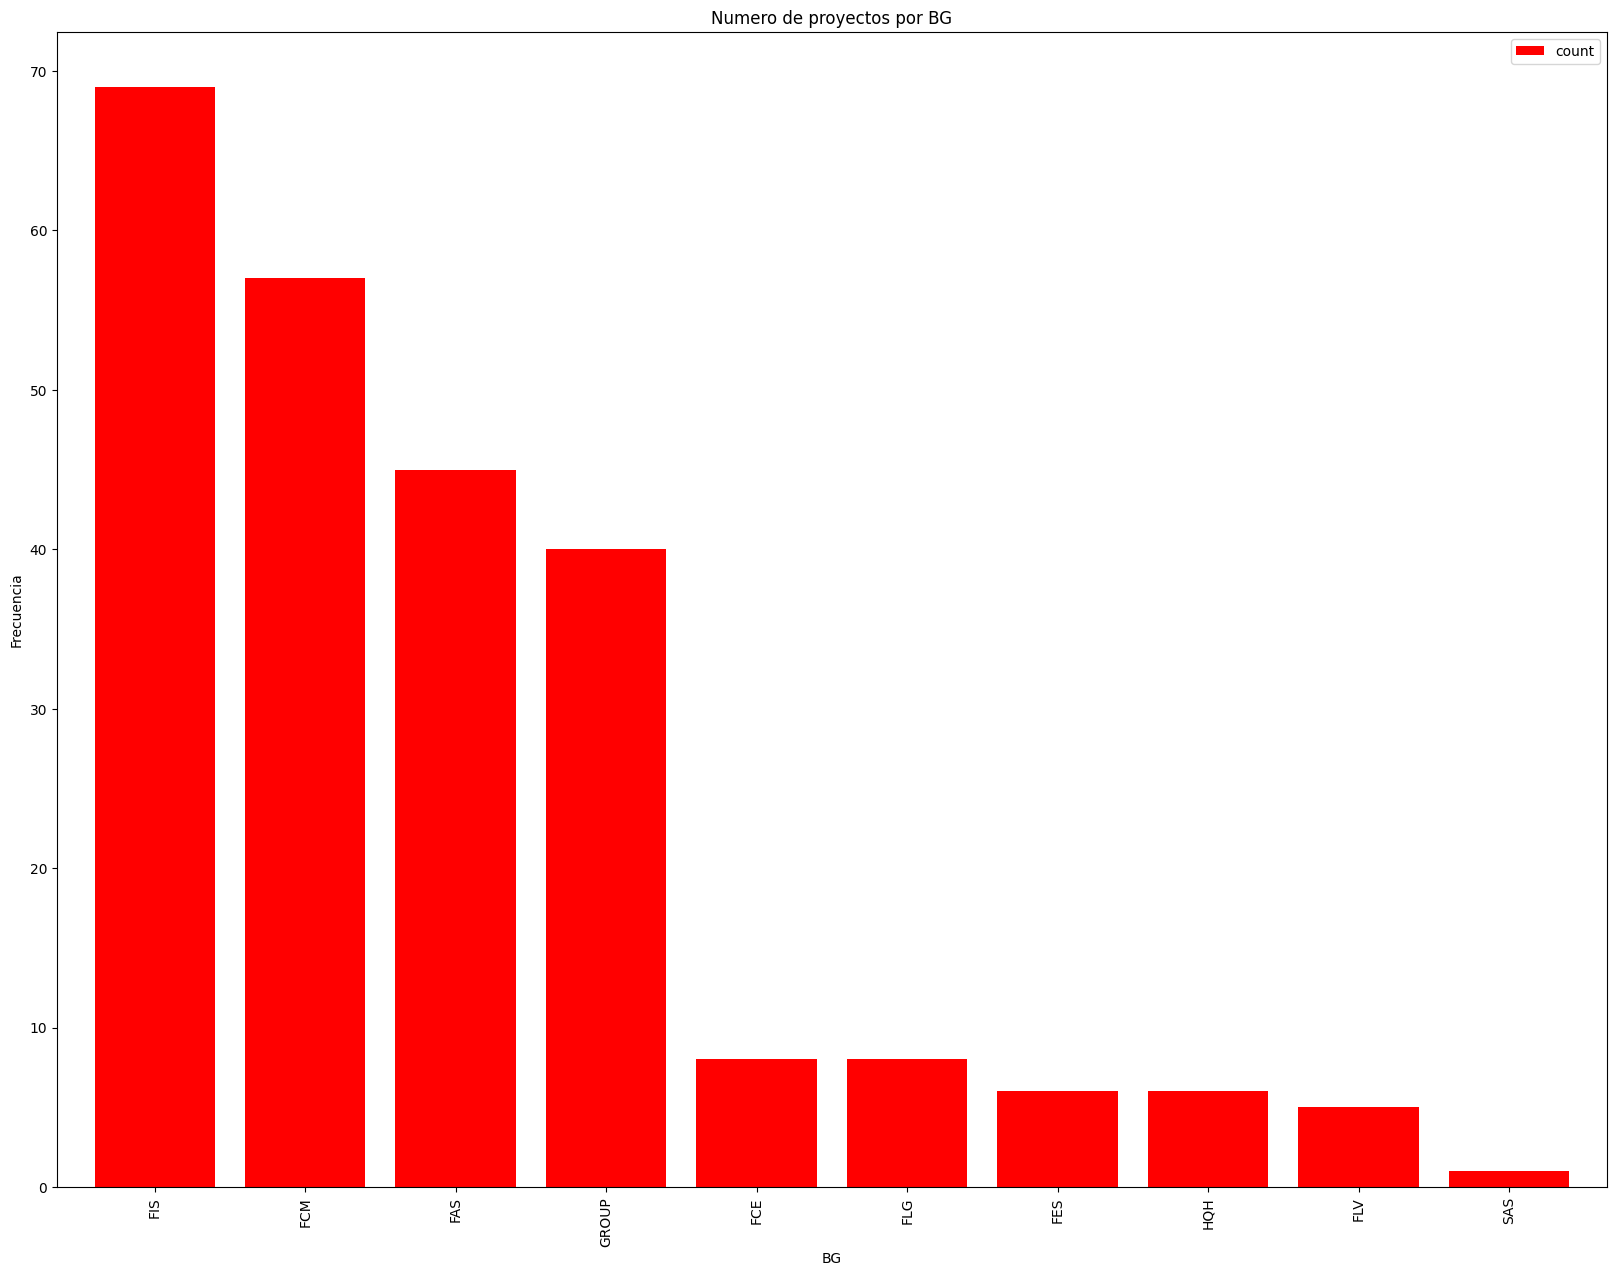

In [118]:
bg_indez=bg.set_index("BG")
bg_indez.plot(kind="bar",width=0.8,figsize= (20,15),color="red")
plt.title("Numero de proyectos por BG")
plt.ylabel("Frecuencia")
plt.xlabel("BG")

In [119]:
project_health = df["Project Health"].value_counts().reset_index()
project_health

,Project Health,count
0,Green,183
1,Yellow,49
2,Sin Actualizacion,13


In [120]:
healt_index = project_health.set_index("Project Health")
healt_index

,count
Project Health,
Green,183
Yellow,49
Sin Actualizacion,13


Text(0.5, 0, 'Salud')

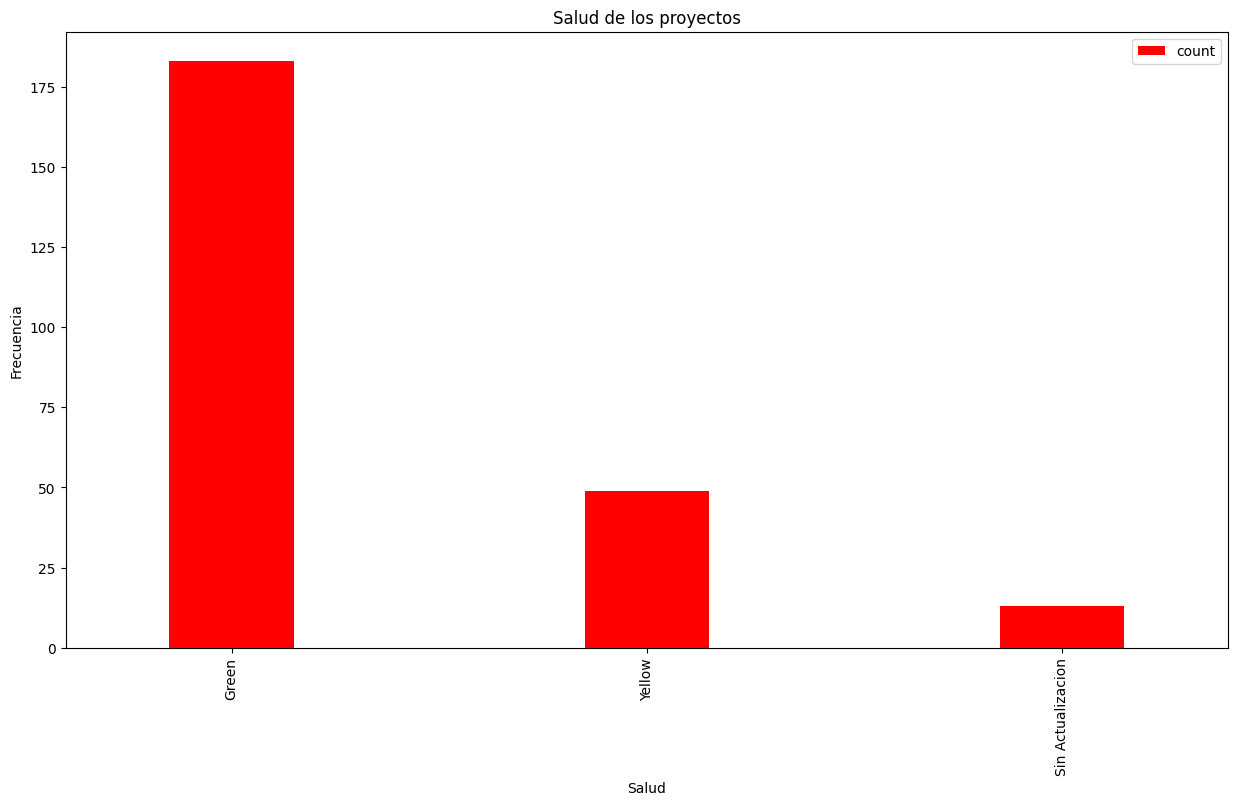

In [121]:
healt_index.plot(kind="bar",width=0.3,figsize= (15,8),color="red")
plt.title("Salud de los proyectos")
plt.ylabel("Frecuencia")
plt.xlabel("Salud")

In [122]:
On_hold=df["On-hold"].value_counts().reset_index()
On_hold

,On-hold,count
0,FALSO,195
1,VERDADERO,50


In [123]:
onhold_index=On_hold.set_index("On-hold")


Text(0.5, 0, 'Proyectos')

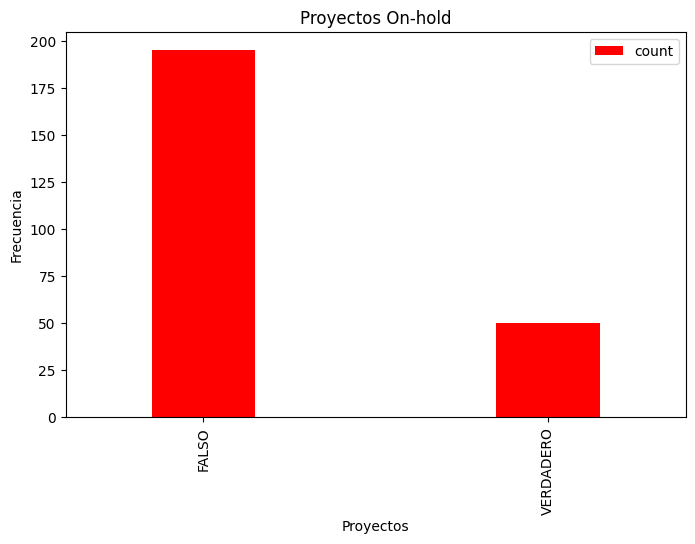

In [124]:
onhold_index.plot(kind="bar",width=0.3,figsize= (8,5),color="red")
plt.title("Proyectos On-hold")
plt.ylabel("Frecuencia")
plt.xlabel("Proyectos")

In [125]:
df["Percent complete"].info()
n=245

<class 'pandas.core.series.Series'>
RangeIndex: 245 entries, 0 to 244
Series name: Percent complete
Non-Null Count  Dtype  
--------------  -----  
245 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


In [126]:
Max=df['Percent complete'].max()
Min=df['Percent complete'].min()
Limites= [Min, Max]
Limites

[np.float64(0.0), np.float64(99.92)]

In [127]:
R=Max-Min
R

np.float64(99.92)

In [128]:
ni= 1+3.32*np.log10(n) #Numero de intervalos
ni

np.float64(8.932031400090247)

In [129]:
i=R/ni
i

np.float64(11.18670496377682)

In [130]:
intervalos=np.linspace(-0.1, 99.93, 9)  #Minimo, Maximo, numero de intervalos
intervalos

array([-0.1    , 12.40375, 24.9075 , 37.41125, 49.915  , 62.41875,
       74.9225 , 87.42625, 99.93   ])

In [131]:
categorias= ["Categoría1 (0 a 12%)", "Categoría2 (12% a 24%)","Categoría3 (24% a 37%)", "Categoría4 (37% a 45%)",
             "Categoría5 (45% a 62%)", "Categoría6 (62% a 75%)","Categoría7 (75% a 87%)", "Categoría8 (87% a 100%)"]

In [132]:
df['Percent complete']=pd.cut(x= df['Percent complete'], bins=intervalos, labels= categorias)
df['Percent complete']

0       Categoría3 (24% a 37%)
1       Categoría5 (45% a 62%)
2      Categoría8 (87% a 100%)
3       Categoría2 (12% a 24%)
4       Categoría2 (12% a 24%)
                ...           
240       Categoría1 (0 a 12%)
241    Categoría8 (87% a 100%)
242       Categoría1 (0 a 12%)
243     Categoría7 (75% a 87%)
244       Categoría1 (0 a 12%)
Name: Percent complete, Length: 245, dtype: category
Categories (8, object): ['Categoría1 (0 a 12%)' < 'Categoría2 (12% a 24%)' < 'Categoría3 (24% a 37%)' < 'Categoría4 (37% a 45%)' < 'Categoría5 (45% a 62%)' < 'Categoría6 (62% a 75%)' < 'Categoría7 (75% a 87%)' < 'Categoría8 (87% a 100%)']

In [133]:
Tabla_freq = df['Percent complete'].value_counts().reset_index()
Tabla_freq

,Percent complete,count
0,Categoría1 (0 a 12%),77
1,Categoría8 (87% a 100%),47
2,Categoría2 (12% a 24%),37
3,Categoría3 (24% a 37%),30
4,Categoría4 (37% a 45%),16
5,Categoría7 (75% a 87%),14
6,Categoría5 (45% a 62%),13
7,Categoría6 (62% a 75%),11


In [134]:
Filtro_index= Tabla_freq.set_index('Percent complete')
Filtro_index

,count
Percent complete,
Categoría1 (0 a 12%),77
Categoría8 (87% a 100%),47
Categoría2 (12% a 24%),37
Categoría3 (24% a 37%),30
Categoría4 (37% a 45%),16
Categoría7 (75% a 87%),14
Categoría5 (45% a 62%),13
Categoría6 (62% a 75%),11


Text(0, 0.5, 'Frecuencia')

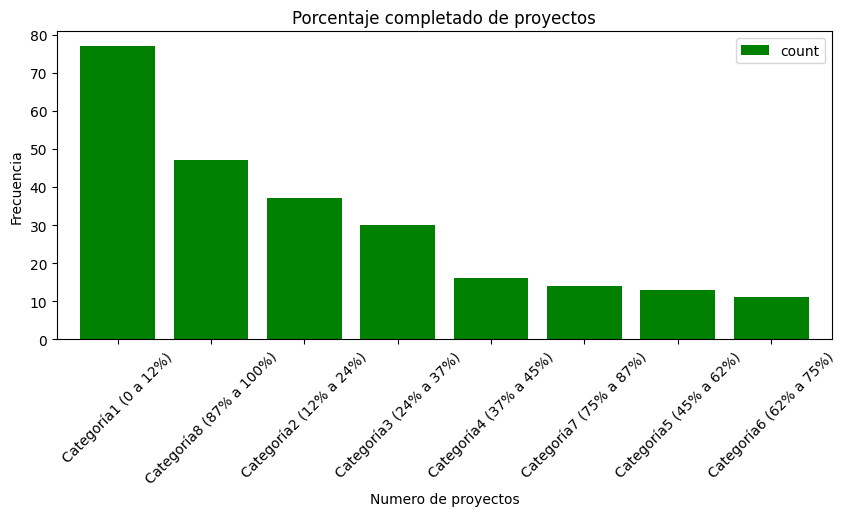

In [137]:
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "green", rot=45)
plt.title('Porcentaje completado de proyectos')
plt.xlabel('Numero de proyectos')
plt.ylabel('Frecuencia')

In [138]:
df.to_csv("projectos_forvia_limpio.csv")